# Module Imports 

### Note that project root path should be in your OS path so that you can access other modules in your project while in this jupyter notebook

In [1]:
import scipy.io as sio
import pandas as pd
import numpy as np
import sys, os
import torch
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from data_classes.decomposition import Extract_Features
import matplotlib.pyplot as plt
import models.classification as classify
import models.loops as loops
import models.models as models
import librosa

# Loading and Preparing Data

## Phase 1

### I have used pandas here to prepare a table like dataframe to store the data.
df_X is the dataframe for audio samples \
df_X is the dataframe for audio labels

In [2]:
# load & preprocess
P1_data = sio.loadmat('../data/mine_impact_data_2019.mat')
P1_samples = pd.DataFrame(P1_data['x'].T)
P1_labels  = pd.DataFrame(P1_data['y'].T, columns=['y'])
P1_df = pd.concat([P1_samples, P1_labels], axis=1).dropna().sample(frac=1, random_state=42)
shuffled_df = P1_df.sample(frac=1, random_state=42).reset_index(drop=True)
P1_df_X = shuffled_df.iloc[:, :-1]
P1_df_Y = shuffled_df.iloc[:, -1]


### Data can be extracted using Extract_Features
**Use Extract_Features object from ../data_classes/decomposition.py**

**Use "feature" argument in Extract_Features to choose which feature extraction method you want or add your own if you want.**

**By default Extract_Features returns a Pytorch dataset to be used for pytorch train/test/val loops**

In [3]:
## Look into Extract_Features class in ../data_classes/decomposition.py for available feature extraction methods.

## This is how you get raw audio data as a Pytorch dataset
P1_raw = Extract_Features(P1_df_X, P1_df_Y, feature='raw')

In [50]:
## This is how you can extract fetaures in the form of numpy arrays
print(P1_raw.get_samples().shape, P1_raw.get_labels().shape)

(3309, 36000) (3309,)


### Waveform Visualisation

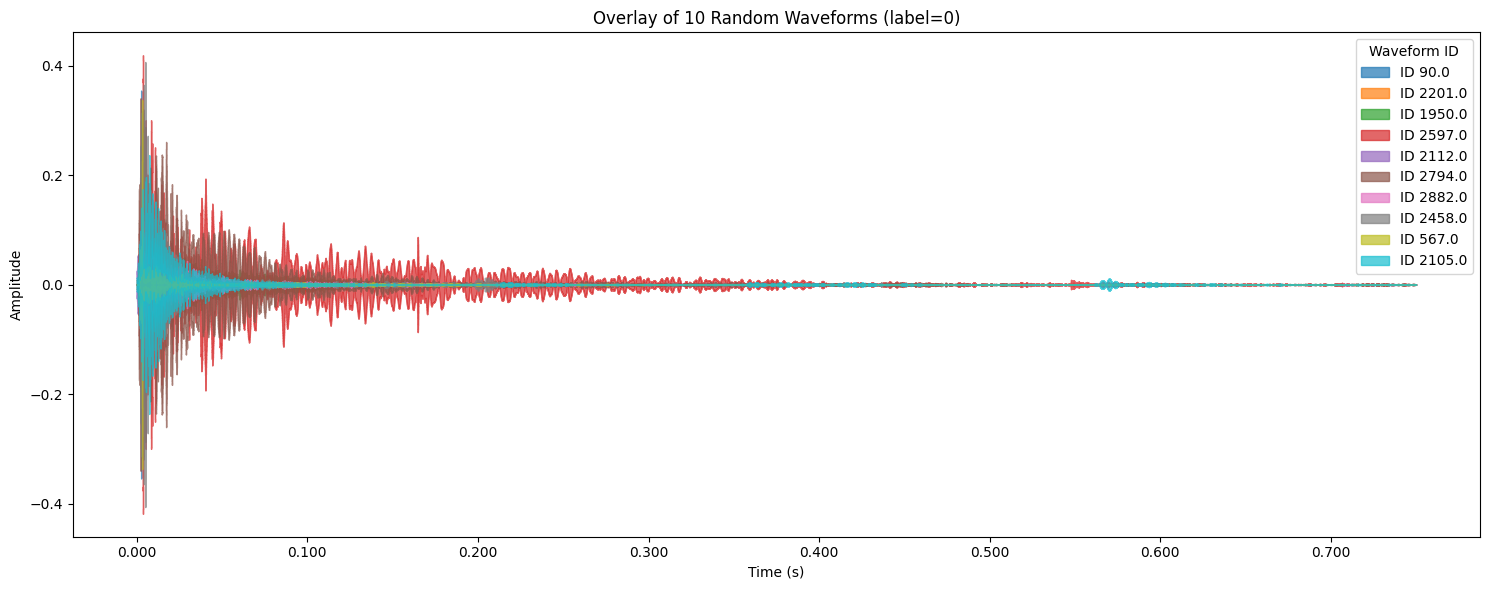

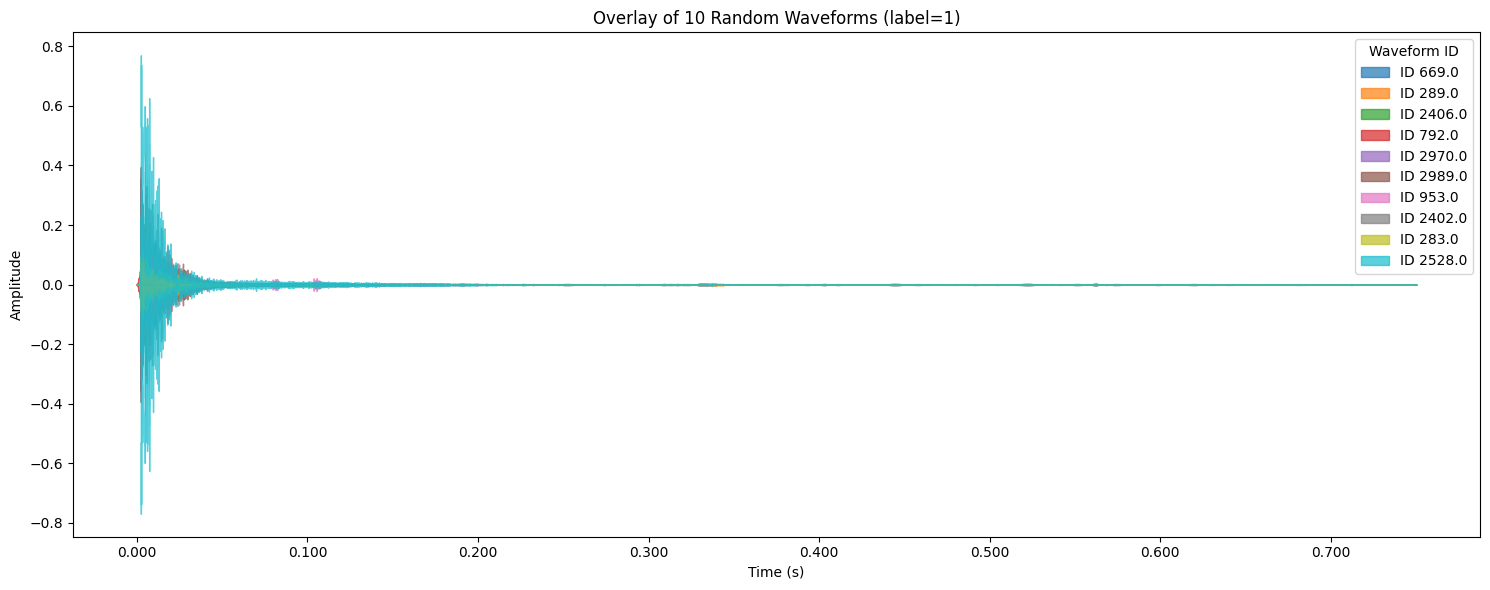

In [6]:
import matplotlib.cm as cm
import numpy as np
import librosa.display

P1_sr = 48000
samples = P1_df[P1_df['y'] == 0].sample(10).reset_index(drop=False)

plt.figure(figsize=(15, 6))
colors = cm.tab10(np.linspace(0, 1, len(samples)))

for color, (_, row) in zip(colors, samples.iterrows()):
    wave_id = row['index']  
    example = row.drop(['index', 'y']).values.astype(float)
    librosa.display.waveshow(example,
                             sr=P1_sr,
                             alpha=0.7,
                             color=color,
                             label=f'ID {wave_id}')

plt.title('Overlay of 10 Random Waveforms (label=0)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend(title='Waveform ID')
plt.tight_layout()
plt.show()

samples = P1_df[P1_df['y'] == 1].sample(10).reset_index(drop=False)

plt.figure(figsize=(15, 6))
colors = cm.tab10(np.linspace(0, 1, len(samples)))

for color, (_, row) in zip(colors, samples.iterrows()):
    wave_id = row['index']  
    example = row.drop(['index', 'y']).values.astype(float)
    librosa.display.waveshow(example,
                             sr=P1_sr,
                             alpha=0.7,
                             color=color,
                             label=f'ID {wave_id}')

plt.title('Overlay of 10 Random Waveforms (label=1)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend(title='Waveform ID')
plt.tight_layout()
plt.show()

### PCA Analysis to compare with previous research paper

**PCA feature in extract features lets you choose either explained_variance or number of components you want.**

Use parameter "explained_variance" or "n_components"

In [8]:
P1_PCA = Extract_Features(P1_df_X, P1_df_Y, feature="pca", explained_variance=0.95)

In [9]:
print("Number of components explaining 95% variance:", P1_PCA.get_samples().shape[1])
print(P1_PCA.get_samples().shape, P1_PCA.get_labels().shape)


Number of components explaining 95% variance: 396
(3309, 396) (3309,)


**However to compare performance on different combinations of extracted features and type of classification model used we need to create more pca objects**

In [ ]:
# === PCA EV sweep with fixed nb_hidden {256,128,64,32} + loops.train/test + Plotly ===
torch.manual_seed(42)
np.random.seed(42)
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
import torch
from torch.utils.data import DataLoader, Subset
import plotly.express as px
from IPython.display import display
import os


explained_variances = [0.80, 0.85, 0.90, 0.95, 0.96, 0.97, 0.98, 0.99]
hidden_grid = [256, 128, 64, 32]        #fixed hidden sizes
batch_size = 32
epochs = 20
model_dir = "./final_model_paths"
os.makedirs(model_dir, exist_ok=True)

y_all = P1_df_Y.squeeze().astype(int).values
idx_all = np.arange(len(y_all))
train_idx, test_idx = train_test_split(idx_all, test_size=0.2, random_state=42, stratify=y_all)

results = []

device_str = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

def get_input_dim(X: np.ndarray) -> int:
    # Scalar feature count even if features are not strictly 2D
    return int(np.prod(X.shape[1:]))

for ev in explained_variances:
    #PCA features via Extract_Features
    P1_PCA = Extract_Features(P1_df_X, P1_df_Y, feature="pca", explained_variance=ev)

    # Torch datasets for loops
    full_ds = P1_PCA
    train_ds = Subset(full_ds, train_idx.tolist())
    test_ds  = Subset(full_ds,  test_idx.tolist())

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=False)

    # Numpy arrays for SVM + meta
    X = P1_PCA.get_samples()
    y = P1_PCA.get_labels().squeeze().astype(int)
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    input_dim = get_input_dim(X_train)
    num_classes = int(np.unique(y_all).size)

    #SVM baseline (no hidden layers)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    svm = SVC(kernel="rbf", C=100, gamma="scale", random_state=42)
    svm.fit(X_train_s, y_train)
    svm_acc = accuracy_score(y_test, svm.predict(X_test_s))
    results.append({
        "explained_variance": int(ev * 100),
        "model": "SVM (RBF)",
        "nb_hidden": "—",
        "accuracy": svm_acc,
        "input_dim": input_dim,
        "hidden_layers": "—"
    })

    #MLP variants over fixed hidden sizes
    for h in hidden_grid:
        common_kwargs = {
            "nb_hidden": int(h),
            "input_dim": int(input_dim),
            "output_dim": int(num_classes),
            "dropout_rate": 0.2
        }

        mlp_runs = [
            ("MLP",         "MLP (1-layer)", "mlp1", [h]),
            ("MLP_2_layer", "MLP (2-layer)", "mlp2", [h, h // 2]),
            ("MLP_3_layer", "MLP (3-layer)", "mlp3", [h, h // 2, h // 4]),
        ]

        for ctor_name, pretty, tag, hidden_list in mlp_runs:
            model_ctor = globals().get(ctor_name, getattr(classify, ctor_name))
            model = model_ctor(**common_kwargs)

            model_path = os.path.join(model_dir, f"{tag}_ev{int(ev*100)}_h{h}_P1.pth")

            # Train
            loops.train(
                model=model,
                model_path=model_path,
                train_loader=train_loader,
                val=False,
                val_loader=None,
                batch_size=batch_size,
                lr=1e-3,
                weight_decay=0,
                optim="adam",
                epochs=epochs,
            )

            # Test and get accuracy directly
            acc = loops.test(
                model=model,
                model_path=model_path,
                test_loader=test_loader,
                report=False,   # set True to see confusion matrix / report
                score=True,
                device=device_str
            )

            results.append({
                "explained_variance": int(ev * 100),
                "model": pretty,
                "nb_hidden": str(h),
                "accuracy": acc,
                "input_dim": input_dim,
                "hidden_layers": f"H={hidden_list}"
            })

# ---- Results & Plot ----
df_res = pd.DataFrame(results).sort_values(["explained_variance", "model", "nb_hidden"]).reset_index(drop=True)

# Plot: color = model, line-dash = nb_hidden (so you can see how hidden width impacts each model)
fig = px.line(
    df_res,
    x="explained_variance",
    y="accuracy",
    color="model",
    line_dash="nb_hidden",
    markers=True,
    title="Explained Variance vs Accuracy — SVM & MLP Variants (Hidden sizes: 256, 128, 64, 32)",
    labels={
        "explained_variance": "PCA Explained Variance (%)",
        "accuracy": "Accuracy",
        "model": "Classifier",
        "nb_hidden": "Hidden width (1st layer)",
    },
    hover_data={"input_dim": True, "hidden_layers": True, "accuracy": ":.4f"}
)
fig.update_layout(hovermode="x unified", yaxis_tickformat=".2%", xaxis=dict(automargin=True),
        yaxis=dict(automargin=True))
fig.show()

display(df_res)

[INFO] EPOCH: 1/20
Train loss: 0.912505, Train accuracy: 0.6641
[INFO] EPOCH: 2/20
Train loss: 0.688341, Train accuracy: 0.7253
[INFO] EPOCH: 3/20
Train loss: 0.671297, Train accuracy: 0.7435
[INFO] EPOCH: 4/20
Train loss: 0.637084, Train accuracy: 0.7684
[INFO] EPOCH: 5/20
Train loss: 0.592928, Train accuracy: 0.7643
[INFO] EPOCH: 6/20
Train loss: 0.602746, Train accuracy: 0.7911
[INFO] EPOCH: 7/20
Train loss: 0.564990, Train accuracy: 0.8017
[INFO] EPOCH: 8/20
Train loss: 0.555735, Train accuracy: 0.8145
[INFO] EPOCH: 9/20
Train loss: 0.551868, Train accuracy: 0.8289
[INFO] EPOCH: 10/20
Train loss: 0.543652, Train accuracy: 0.8228
[INFO] EPOCH: 11/20
Train loss: 0.538465, Train accuracy: 0.8394
[INFO] EPOCH: 12/20
Train loss: 0.550249, Train accuracy: 0.8349
[INFO] EPOCH: 13/20
Train loss: 0.529623, Train accuracy: 0.8391
[INFO] EPOCH: 14/20
Train loss: 0.530266, Train accuracy: 0.8470
[INFO] EPOCH: 15/20
Train loss: 0.524026, Train accuracy: 0.8504
[INFO] EPOCH: 16/20
Train loss: 0.

,explained_variance,model,nb_hidden,accuracy,input_dim,hidden_layers
0,80,MLP (1-layer),128,0.814199,87,H=[128]
1,80,MLP (1-layer),256,0.805136,87,H=[256]
2,80,MLP (1-layer),32,0.794562,87,H=[32]
3,80,MLP (1-layer),64,0.808157,87,H=[64]
4,80,MLP (2-layer),128,0.856495,87,"H=[128, 64]"
...,...,...,...,...,...,...
99,99,MLP (3-layer),128,0.850453,1186,"H=[128, 64, 32]"
100,99,MLP (3-layer),256,0.832326,1186,"H=[256, 128, 64]"
101,99,MLP (3-layer),32,0.821752,1186,"H=[32, 16, 8]"
102,99,MLP (3-layer),64,0.839879,1186,"H=[64, 32, 16]"


### Best Combination

[RETRAIN] EV=90%, model=MLP (2-layer), nb_hidden=256
[RETRAIN] Saving checkpoint to -> ./final_model_paths/mlp2_ev90_h256_P1_RETRAIN.pth
[INFO] EPOCH: 1/20
Train loss: 0.608423, Train accuracy: 0.7121
[INFO] EPOCH: 2/20
Train loss: 0.483642, Train accuracy: 0.8304
[INFO] EPOCH: 3/20
Train loss: 0.441747, Train accuracy: 0.8697
[INFO] EPOCH: 4/20
Train loss: 0.370634, Train accuracy: 0.9154
[INFO] EPOCH: 5/20
Train loss: 0.334576, Train accuracy: 0.9380
[INFO] EPOCH: 6/20
Train loss: 0.305719, Train accuracy: 0.9645
[INFO] EPOCH: 7/20
Train loss: 0.290870, Train accuracy: 0.9705
[INFO] EPOCH: 8/20
Train loss: 0.267848, Train accuracy: 0.9830
[INFO] EPOCH: 9/20
Train loss: 0.261431, Train accuracy: 0.9864
[INFO] EPOCH: 10/20
Train loss: 0.247550, Train accuracy: 0.9921
[INFO] EPOCH: 11/20
Train loss: 0.253288, Train accuracy: 0.9906
[INFO] EPOCH: 12/20
Train loss: 0.240318, Train accuracy: 0.9955
[INFO] EPOCH: 13/20
Train loss: 0.230930, Train accuracy: 0.9981
[INFO] EPOCH: 14/20
Train l

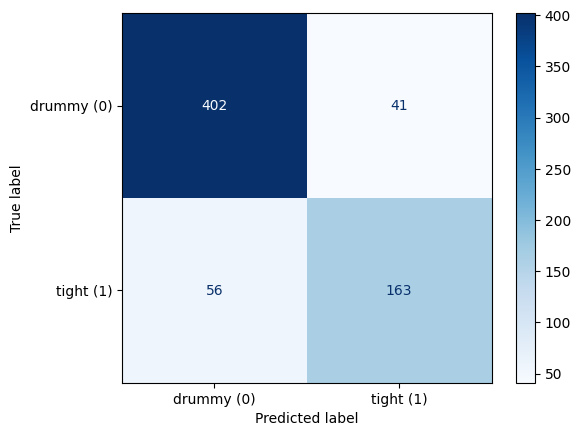


Classification Report:
               precision    recall  f1-score   support

  drummy (0)       0.88      0.91      0.89       443
   tight (1)       0.80      0.74      0.77       219

    accuracy                           0.85       662
   macro avg       0.84      0.83      0.83       662
weighted avg       0.85      0.85      0.85       662

[RETRAIN] Accuracy (report=True): 0.8535
[GRAPH] Saved to: ../assets/final_report_assets/best_model_mlp2_ev90_h256_P1_RETRAIN.png (and/or .pdf)


In [68]:
# === Retrain + Test using the hard-coded best combo, then draw graph ===
torch.manual_seed(42)
np.random.seed(42)

import os, shutil
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

# ----------------- HARD-CODED WINNER -----------------
BEST_EV_PCT     = 90
BEST_MODEL_NAME = "MLP (2-layer)"   # "MLP (1-layer)" | "MLP (2-layer)" | "MLP (3-layer)"
BEST_HIDDEN     = 256               # 256 | 128 | 64 | 32
# -----------------------------------------------------

device_str = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

# Recreate mappings
pretty_to_ctor = {
    "MLP (1-layer)": "MLP",
    "MLP (2-layer)": "MLP_2_layer",
    "MLP (3-layer)": "MLP_3_layer",
}
ctor_to_tag = {"MLP": "mlp1", "MLP_2_layer": "mlp2", "MLP_3_layer": "mlp3"}

ctor_name = pretty_to_ctor[BEST_MODEL_NAME]
tag       = ctor_to_tag[ctor_name]

# Output dirs/paths
model_dir = "./final_model_paths"
os.makedirs(model_dir, exist_ok=True)
# fresh path so we don't rely on old checkpoints
model_path = os.path.join(model_dir, f"{tag}_ev{int(BEST_EV_PCT)}_h{int(BEST_HIDDEN)}_P1_RETRAIN.pth")

print(f"[RETRAIN] EV={BEST_EV_PCT}%, model={BEST_MODEL_NAME}, nb_hidden={BEST_HIDDEN}")
print(f"[RETRAIN] Saving checkpoint to -> {model_path}")

# --- PCA dataset for the chosen EV
best_ev = BEST_EV_PCT / 100.0
P1_PCA_best = Extract_Features(P1_df_X, P1_df_Y, feature="pca", explained_variance=best_ev)

# Split (same seed/stratify as before)
y_all = P1_df_Y.squeeze().astype(int).values
idx_all = np.arange(len(y_all))
train_idx, test_idx = train_test_split(idx_all, test_size=0.2, random_state=42, stratify=y_all)

# Torch loaders
full_ds   = P1_PCA_best
train_ds  = Subset(full_ds, train_idx.tolist())
test_ds   = Subset(full_ds,  test_idx.tolist())
batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=False)

# Infer dims
X_best = P1_PCA_best.get_samples()
input_dim   = int(np.prod(X_best.shape[1:]))
num_classes = int(np.unique(y_all).size)

# Instantiate the winning architecture from models/classification.py
common_kwargs = {
    "nb_hidden": int(BEST_HIDDEN),
    "input_dim": int(input_dim),
    "output_dim": int(num_classes),
    "dropout_rate": 0.2
}
model_ctor = globals().get(ctor_name, getattr(classify, ctor_name))
model = model_ctor(**common_kwargs)

# ----------------- TRAIN -----------------
epochs = 20  # adjust if you want
loops.train(
    model=model,
    model_path=model_path,
    train_loader=train_loader,
    val=False,
    val_loader=None,
    batch_size=batch_size,
    lr=1e-3,
    weight_decay=0,
    optim="adam",
    epochs=epochs,
)

# ----------------- TEST (with report) -----------------
acc = loops.test(
    model=model,
    model_path=model_path,
    test_loader=test_loader,
    report=True,   # show confusion matrix + classification report
    score=True,
    device=device_str
)
print(f"[RETRAIN] Accuracy (report=True): {acc:.4f}")

# ----------------- DRAW GRAPH -----------------
import shutil as _shutil
dot = _shutil.which("dot") or "/opt/homebrew/bin/dot"
if not os.path.exists(dot):
    dot = "/usr/local/bin/dot"
os.environ["GRAPHVIZ_DOT"] = dot
os.environ["PATH"] += os.pathsep + os.path.dirname(dot)

from torchview import draw_graph

model.eval()
graph_fname = f"../assets/final_report_assets/best_model_{tag}_ev{int(BEST_EV_PCT)}_h{int(BEST_HIDDEN)}_P1_RETRAIN"
graph = draw_graph(
    model,
    input_size=(1, input_dim),  # MLP expects (batch, features)
    expand_nested=True,
    device='cpu',
    save_graph=True,
    filename=graph_fname,
)
print(f"[GRAPH] Saved to: {graph_fname}.png (and/or .pdf)")

## Phase 2

### Loading Phase 2 data similar to phase 1 , but removed NaN rows and mis-hits with manually identified indices

In [5]:
# load & preprocess
P2_data = sio.loadmat('../data/phase2_data_20220215.mat')
P2_samples = pd.DataFrame(P2_data['x'].T)
P2_labels  = pd.DataFrame(P2_data['y'].T, columns=['y'])
P2_df = pd.concat([P2_samples, P2_labels], axis=1)
bad_indices = [
    100,303,496,507,609,706,909,1011,1113,1271,1373,1475,1577,1679,1781,1883,2085,2287,
    2389,2489,2789,2891,2895,2995,3096,3497,3767,3997,4099,4201,4499,4699,5199,5301,
    5302,5500,7688,7690,7691,7692,7696,7702,7704,7708,7715,7723,7727,7810,7841,7870,
    7888,7936,7941,7965,7997,8061,8080,8081,8095,8098,8124,8125,8126,8127,8128,8132,
    8156,8157,8158,8159,8160,8161,8215,8261,8302,8310,8322,8395,8425,8477,8478,8479,
    8483,8487,8491,8496,8527,8563,8587,8642,8743,8848,
    0,94,98,102,203,403,505,607,611,708,809,1009,1111,1171,1273,1473,1575,1579,1635,
    1660,1674,1681,1881,1983,1985,2087,2088,2187,2246,2387,2589,2689,2791,2893,3196,
    3455,3495,3696,3798,3999,4199,4701,4748,4749,4798,4999,5201,5209,5244,5245,5255,
    5924,5945,5977,6128,6135,6229,6271,6299,6377,6383,6388,6389,6678,6760,6903,6906,
    6935,6936,7430,7582,7694,7698,7699,7700,7706,7710,7713,7717,7718,7777,7778,7856,
    7872,7939,7943,7960,7984,7999,8046,8048,8059,8063,8064,8068,8078,8083,8084,8085,
    8093,8165,8166,8191,8308,8366,8397,8398,8481,8485,8489,8493,8494,8498,8544,8565,
    8640,8692,8798,8902
]

P2_df = P2_df.drop(index=bad_indices, errors='ignore')
P2_df = P2_df.dropna()

shuffled_df = P2_df.sample(frac=1, random_state=42).reset_index(drop=True)
P2_df_X = shuffled_df.iloc[:, :-1]
P2_df_Y = shuffled_df.iloc[:, -1]

### Extracting raw features in torch dataset form

In [6]:
P2_raw = Extract_Features(P2_df_X, P2_df_Y, feature='raw')

In [9]:
## This is how you can extract fetaures in the form of numpy arrays
print(P2_raw.get_samples().shape, P2_raw.get_labels().shape)

(8229, 4800) (8229,)


### Waveform Visualisation

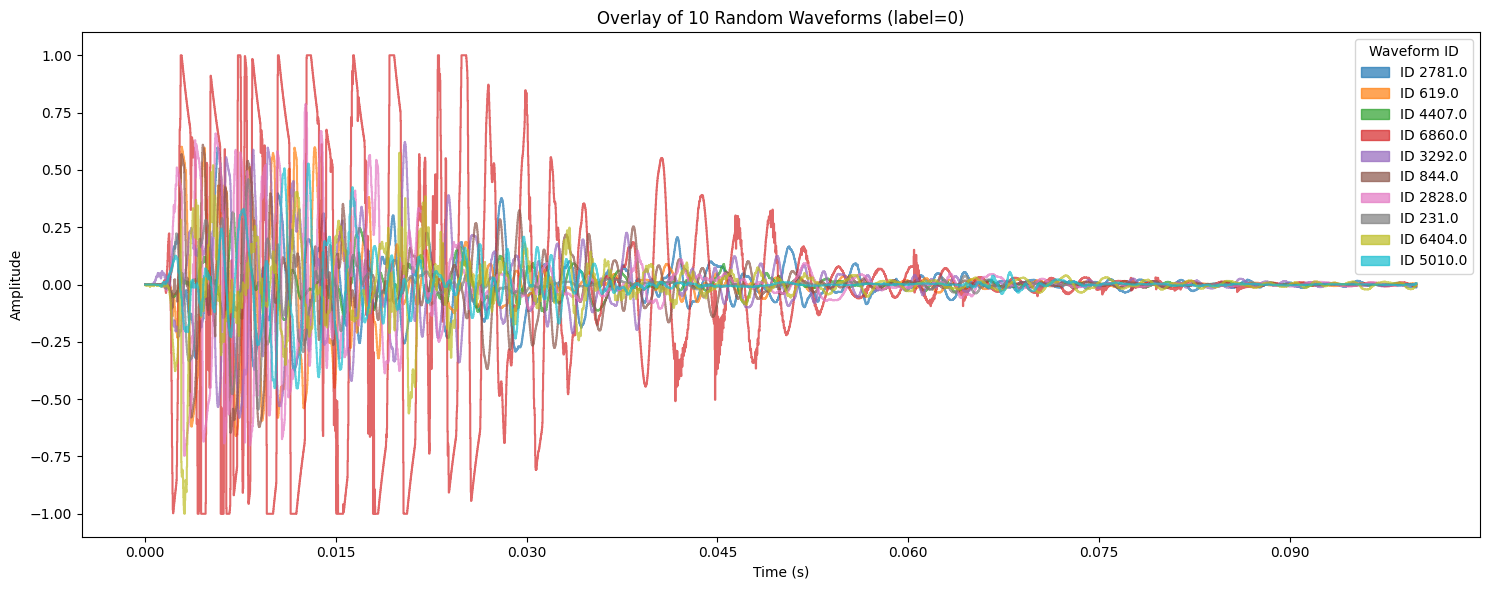

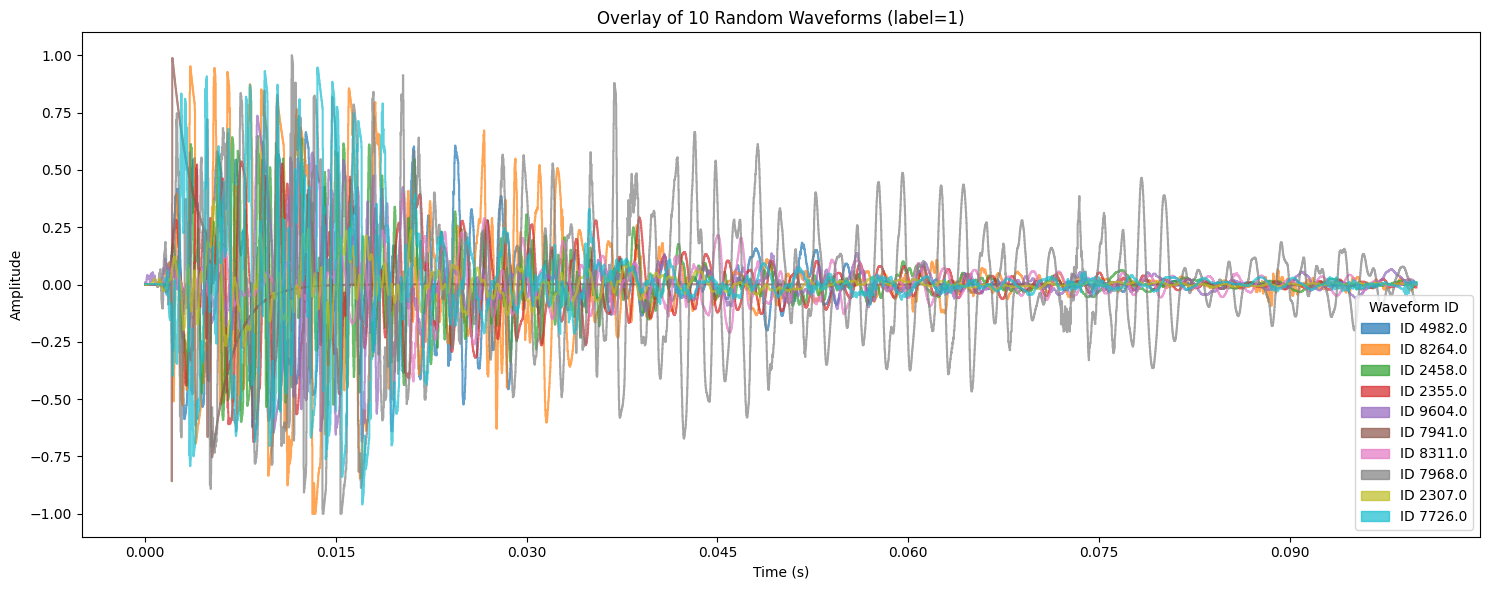

In [72]:
import matplotlib.cm as cm
import numpy as np
import librosa.display

P2_sr = 48000
samples = P2_df[P2_df['y'] == 0].sample(10).reset_index(drop=False)

plt.figure(figsize=(15, 6))
colors = cm.tab10(np.linspace(0, 1, len(samples)))

for color, (_, row) in zip(colors, samples.iterrows()):
    wave_id = row['index']  
    example = row.drop(['index', 'y']).values.astype(float)
    librosa.display.waveshow(example,
                             sr=P2_sr,
                             alpha=0.7,
                             color=color,
                             label=f'ID {wave_id}')

plt.title('Overlay of 10 Random Waveforms (label=0)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend(title='Waveform ID')
plt.tight_layout()
plt.show()
samples = P2_df[P2_df['y'] == 1].sample(10).reset_index(drop=False)

plt.figure(figsize=(15, 6))
colors = cm.tab10(np.linspace(0, 1, len(samples)))

for color, (_, row) in zip(colors, samples.iterrows()):
    wave_id = row['index']  
    example = row.drop(['index', 'y']).values.astype(float)
    librosa.display.waveshow(example,
                             sr=P2_sr,
                             alpha=0.7,
                             color=color,
                             label=f'ID {wave_id}')

plt.title('Overlay of 10 Random Waveforms (label=1)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend(title='Waveform ID')
plt.tight_layout()
plt.show()

### PCA Analysis to compare with previous research paper

**Comparing performance on different combinations of extracted features and type of classification model used we need to create more pca objects**

In [ ]:
# === PCA EV sweep with fixed nb_hidden {128,64,32} + loops.train/test + Plotly ===
torch.manual_seed(42)
np.random.seed(42)
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
import torch
from torch.utils.data import DataLoader, Subset
import plotly.express as px
from IPython.display import display
import os

explained_variances = [0.80, 0.85, 0.90, 0.95, 0.96, 0.97, 0.98, 0.99]
hidden_grid = [128, 64, 32]        #fixed hidden sizes
batch_size = 90
epochs = 20
model_dir = "./final_model_paths"
os.makedirs(model_dir, exist_ok=True)

y_all = P2_df_Y.squeeze().astype(int).values
idx_all = np.arange(len(y_all))
train_idx, test_idx = train_test_split(idx_all, test_size=0.2, random_state=42, stratify=y_all)

results = []

device_str = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

def get_input_dim(X: np.ndarray) -> int:
    # Scalar feature count even if features are not strictly 2D
    return int(np.prod(X.shape[1:]))

for ev in explained_variances:
    #PCA features via your Extract_Features
    P2_PCA = Extract_Features(P2_df_X, P2_df_Y, feature="pca", explained_variance=ev)

    # Torch datasets for loops
    full_ds = P2_PCA
    train_ds = Subset(full_ds, train_idx.tolist())
    test_ds  = Subset(full_ds,  test_idx.tolist())

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=False)

    # Numpy arrays for SVM + meta
    X = P2_PCA.get_samples()
    y = P2_PCA.get_labels().squeeze().astype(int)
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    input_dim = get_input_dim(X_train)
    num_classes = int(np.unique(y_all).size)

    #SVM baseline (no hidden layers)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    svm = SVC(kernel="rbf", C=100, gamma="scale", random_state=42)
    svm.fit(X_train_s, y_train)
    svm_acc = accuracy_score(y_test, svm.predict(X_test_s))
    results.append({
        "explained_variance": int(ev * 100),
        "model": "SVM (RBF)",
        "nb_hidden": "—",
        "accuracy": svm_acc,
        "input_dim": input_dim,
        "hidden_layers": "—"
    })

    #MLP variants over fixed hidden sizes
    for h in hidden_grid:
        common_kwargs = {
            "nb_hidden": int(h),
            "input_dim": int(input_dim),
            "output_dim": int(num_classes),
            "dropout_rate": 0.2
        }

        mlp_runs = [
            ("MLP",         "MLP (1-layer)", "mlp1", [h]),
            ("MLP_2_layer", "MLP (2-layer)", "mlp2", [h, h // 2]),
            ("MLP_3_layer", "MLP (3-layer)", "mlp3", [h, h // 2, h // 4]),
        ]

        for ctor_name, pretty, tag, hidden_list in mlp_runs:
            model_ctor = globals().get(ctor_name, getattr(classify, ctor_name))
            model = model_ctor(**common_kwargs)

            model_path = os.path.join(model_dir, f"{tag}_ev{int(ev*100)}_h{h}_P2.pth")

            # Train 
            loops.train(
                model=model,
                model_path=model_path,
                train_loader=train_loader,
                val=False,
                val_loader=None,
                batch_size=batch_size,
                lr=1e-3,
                weight_decay=0,
                optim="adam",
                epochs=epochs,
            )

            # Test and get accuracy directly
            acc = loops.test(
                model=model,
                model_path=model_path,
                test_loader=test_loader,
                report=False,   # set True to see confusion matrix / report
                score=True,
                device=device_str
            )

            results.append({
                "explained_variance": int(ev * 100),
                "model": pretty,
                "nb_hidden": str(h),
                "accuracy": acc,
                "input_dim": input_dim,
                "hidden_layers": f"H={hidden_list}"
            })

df_res = pd.DataFrame(results).sort_values(["explained_variance", "model", "nb_hidden"]).reset_index(drop=True)

#color = model, line-dash = nb_hidden (so you can see how hidden width impacts each model)
fig = px.line(
    df_res,
    x="explained_variance",
    y="accuracy",
    color="model",
    line_dash="nb_hidden",
    markers=True,
    title="Explained Variance vs Accuracy — SVM & MLP Variants (Hidden sizes:128, 64, 32)",
    labels={
        "explained_variance": "PCA Explained Variance (%)",
        "accuracy": "Accuracy",
        "model": "Classifier",
        "nb_hidden": "Hidden width (1st layer)",
    },
    hover_data={"input_dim": True, "hidden_layers": True, "accuracy": ":.4f"}
)
fig.update_layout(hovermode="x unified", yaxis_tickformat=".2%", xaxis=dict(automargin=True),
        yaxis=dict(automargin=True))
fig.show()

display(df_res)

[INFO] EPOCH: 1/20
Train loss: 0.767419, Train accuracy: 0.5964
[INFO] EPOCH: 2/20
Train loss: 0.642835, Train accuracy: 0.6802
[INFO] EPOCH: 3/20
Train loss: 0.618082, Train accuracy: 0.7022
[INFO] EPOCH: 4/20
Train loss: 0.578876, Train accuracy: 0.7319
[INFO] EPOCH: 5/20
Train loss: 0.568869, Train accuracy: 0.7382
[INFO] EPOCH: 6/20
Train loss: 0.555528, Train accuracy: 0.7605
[INFO] EPOCH: 7/20
Train loss: 0.545308, Train accuracy: 0.7755
[INFO] EPOCH: 8/20
Train loss: 0.540854, Train accuracy: 0.7759
[INFO] EPOCH: 9/20
Train loss: 0.521796, Train accuracy: 0.7876
[INFO] EPOCH: 10/20
Train loss: 0.507886, Train accuracy: 0.8012
[INFO] EPOCH: 11/20
Train loss: 0.517677, Train accuracy: 0.7916
[INFO] EPOCH: 12/20
Train loss: 0.501295, Train accuracy: 0.8101
[INFO] EPOCH: 13/20
Train loss: 0.492962, Train accuracy: 0.8122
[INFO] EPOCH: 14/20
Train loss: 0.496951, Train accuracy: 0.8162
[INFO] EPOCH: 15/20
Train loss: 0.487138, Train accuracy: 0.8152
[INFO] EPOCH: 16/20
Train loss: 0.

,explained_variance,model,nb_hidden,accuracy,input_dim,hidden_layers
0,80,MLP (1-layer),128,0.763033,99,H=[128]
1,80,MLP (1-layer),32,0.743483,99,H=[32]
2,80,MLP (1-layer),64,0.747630,99,H=[64]
3,80,MLP (2-layer),128,0.750000,99,"H=[128, 64]"
4,80,MLP (2-layer),32,0.752370,99,"H=[32, 16]"
...,...,...,...,...,...,...
75,99,MLP (2-layer),64,0.775474,565,"H=[64, 32]"
76,99,MLP (3-layer),128,0.792062,565,"H=[128, 64, 32]"
77,99,MLP (3-layer),32,0.768365,565,"H=[32, 16, 8]"
78,99,MLP (3-layer),64,0.765995,565,"H=[64, 32, 16]"


### Best Combination

[RETRAIN] EV=96%, model=MLP (1-layer), nb_hidden=128
[RETRAIN] Saving checkpoint to -> ./final_model_paths/mlp1_ev96_h128_P2_RETRAIN.pth
[INFO] EPOCH: 1/20
Train loss: 0.680238, Train accuracy: 0.6474
[INFO] EPOCH: 2/20
Train loss: 0.564625, Train accuracy: 0.7494
[INFO] EPOCH: 3/20
Train loss: 0.504160, Train accuracy: 0.7955
[INFO] EPOCH: 4/20
Train loss: 0.469787, Train accuracy: 0.8276
[INFO] EPOCH: 5/20
Train loss: 0.440636, Train accuracy: 0.8500
[INFO] EPOCH: 6/20
Train loss: 0.435182, Train accuracy: 0.8599
[INFO] EPOCH: 7/20
Train loss: 0.415671, Train accuracy: 0.8754
[INFO] EPOCH: 8/20
Train loss: 0.397861, Train accuracy: 0.8911
[INFO] EPOCH: 9/20
Train loss: 0.394211, Train accuracy: 0.8914
[INFO] EPOCH: 10/20
Train loss: 0.381087, Train accuracy: 0.9077
[INFO] EPOCH: 11/20
Train loss: 0.382090, Train accuracy: 0.9114
[INFO] EPOCH: 12/20
Train loss: 0.374047, Train accuracy: 0.9107
[INFO] EPOCH: 13/20
Train loss: 0.365308, Train accuracy: 0.9166
[INFO] EPOCH: 14/20
Train l

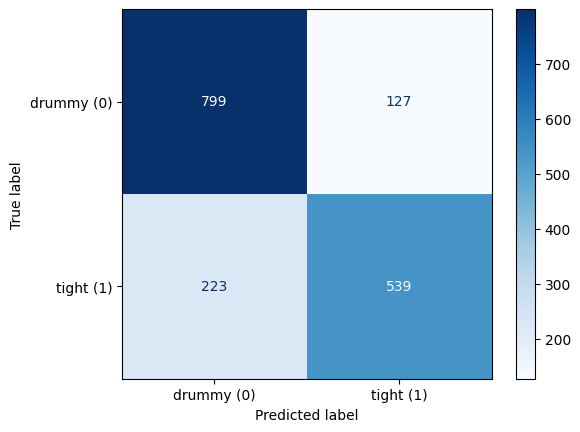


Classification Report:
               precision    recall  f1-score   support

  drummy (0)       0.78      0.86      0.82       926
   tight (1)       0.81      0.71      0.75       762

    accuracy                           0.79      1688
   macro avg       0.80      0.79      0.79      1688
weighted avg       0.79      0.79      0.79      1688

[RETRAIN] Accuracy (report=True): 0.7927
[GRAPH] Saved to: ../assets/final_report_assets/best_model_mlp1_ev96_h128_P2_RETRAIN.png (and/or .pdf)


In [74]:
# === Retrain + Test using the hard-coded best combo, then draw graph ===
torch.manual_seed(42)
np.random.seed(42)

import os, shutil
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

# ----------------- HARD-CODED WINNER -----------------
BEST_EV_PCT     = 96
BEST_MODEL_NAME = "MLP (1-layer)"   # "MLP (1-layer)" | "MLP (2-layer)" | "MLP (3-layer)"
BEST_HIDDEN     = 128               # 128 | 64 | 32
# -----------------------------------------------------

device_str = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

# Recreate mappings
pretty_to_ctor = {
    "MLP (1-layer)": "MLP",
    "MLP (2-layer)": "MLP_2_layer",
    "MLP (3-layer)": "MLP_3_layer",
}
ctor_to_tag = {"MLP": "mlp1", "MLP_2_layer": "mlp2", "MLP_3_layer": "mlp3"}

ctor_name = pretty_to_ctor[BEST_MODEL_NAME]
tag       = ctor_to_tag[ctor_name]

# Output dirs/paths
model_dir = "./final_model_paths"
os.makedirs(model_dir, exist_ok=True)
# fresh path so we don't rely on old checkpoints
model_path = os.path.join(model_dir, f"{tag}_ev{int(BEST_EV_PCT)}_h{int(BEST_HIDDEN)}_P2_RETRAIN.pth")

print(f"[RETRAIN] EV={BEST_EV_PCT}%, model={BEST_MODEL_NAME}, nb_hidden={BEST_HIDDEN}")
print(f"[RETRAIN] Saving checkpoint to -> {model_path}")

# --- PCA dataset for the chosen EV
best_ev = BEST_EV_PCT / 100.0
P2_PCA_best = Extract_Features(P2_df_X, P2_df_Y, feature="pca", explained_variance=best_ev)

# Split (same seed/stratify as before)
y_all = P2_df_Y.squeeze().astype(int).values
idx_all = np.arange(len(y_all))
train_idx, test_idx = train_test_split(idx_all, test_size=0.2, random_state=42, stratify=y_all)

# Torch loaders
full_ds   = P2_PCA_best
train_ds  = Subset(full_ds, train_idx.tolist())
test_ds   = Subset(full_ds,  test_idx.tolist())
batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=False)

# Infer dims
X_best = P2_PCA_best.get_samples()
input_dim   = int(np.prod(X_best.shape[1:]))
num_classes = int(np.unique(y_all).size)

# Instantiate the winning architecture from models/classification.py
common_kwargs = {
    "nb_hidden": int(BEST_HIDDEN),
    "input_dim": int(input_dim),
    "output_dim": int(num_classes),
    "dropout_rate": 0.2
}
model_ctor = globals().get(ctor_name, getattr(classify, ctor_name))
model = model_ctor(**common_kwargs)

# ----------------- TRAIN -----------------
epochs = 20  # adjust if you want
loops.train(
    model=model,
    model_path=model_path,
    train_loader=train_loader,
    val=False,
    val_loader=None,
    batch_size=batch_size,
    lr=1e-3,
    weight_decay=0,
    optim="adam",
    epochs=epochs,
)

# ----------------- TEST (with report) -----------------
acc = loops.test(
    model=model,
    model_path=model_path,
    test_loader=test_loader,
    report=True,   # show confusion matrix + classification report
    score=True,
    device=device_str
)
print(f"[RETRAIN] Accuracy (report=True): {acc:.4f}")

# ----------------- DRAW GRAPH -----------------
import shutil as _shutil
dot = _shutil.which("dot") or "/opt/homebrew/bin/dot"
if not os.path.exists(dot):
    dot = "/usr/local/bin/dot"
os.environ["GRAPHVIZ_DOT"] = dot
os.environ["PATH"] += os.pathsep + os.path.dirname(dot)

from torchview import draw_graph

model.eval()
graph_fname = f"../assets/final_report_assets/best_model_{tag}_ev{int(BEST_EV_PCT)}_h{int(BEST_HIDDEN)}_P2_RETRAIN"
graph = draw_graph(
    model,
    input_size=(1, input_dim),  # MLP expects (batch, features)
    expand_nested=True,
    device='cpu',
    save_graph=True,
    filename=graph_fname,
)
print(f"[GRAPH] Saved to: {graph_fname}.png (and/or .pdf)")

# Temporal Feature Extraction Methods

### Extract_Features class can extract temporal features such as "rms_energy", "amplitude_envelope" and "zero_crossing_rate"

In [ ]:
frame_size = 128
hop_length = 128

# Note temporal features need frame_size and hop_length as arguments in Extract_Features object
P1_amp_env = Extract_Features(P1_df_X, P1_df_Y, feature="amplitude_envelope", frame_size=frame_size, hop_length=hop_length)
P1_zcr = Extract_Features(P1_df_X, P1_df_Y, feature="zero_crossing_rate", frame_size=frame_size, hop_length=hop_length)
P1_rms = Extract_Features(P1_df_X, P1_df_Y, feature="rms_energy", frame_size=frame_size, hop_length=hop_length)

In [11]:
## This is how you can extract features in the form of numpy arrays
print(P1_amp_env.get_samples().shape, P1_amp_env.get_labels().shape)
print(P1_zcr.get_samples().shape, P1_zcr.get_labels().shape)
print(P1_rms.get_samples().shape, P1_rms.get_labels().shape)

(3309, 281) (3309,)
(3309, 282) (3309,)
(3309, 282) (3309,)


### This is how you start the training routine by using models from classification.py and models.py

#### Example classification on P1_zcr
#### You can change frame_size and hop_length to get different length of feature vector

torch.Size([282])
[INFO] EPOCH: 1/20
Train loss: 0.692920, Train accuracy: 0.5833
[INFO] EPOCH: 2/20
Train loss: 0.600081, Train accuracy: 0.7410
[INFO] EPOCH: 3/20
Train loss: 0.551097, Train accuracy: 0.7780
[INFO] EPOCH: 4/20
Train loss: 0.532601, Train accuracy: 0.7843
[INFO] EPOCH: 5/20
Train loss: 0.524158, Train accuracy: 0.7943
[INFO] EPOCH: 6/20
Train loss: 0.524962, Train accuracy: 0.7900
[INFO] EPOCH: 7/20
Train loss: 0.510799, Train accuracy: 0.7993
[INFO] EPOCH: 8/20
Train loss: 0.501709, Train accuracy: 0.8120
[INFO] EPOCH: 9/20
Train loss: 0.491303, Train accuracy: 0.8183
[INFO] EPOCH: 10/20
Train loss: 0.482771, Train accuracy: 0.8230
[INFO] EPOCH: 11/20
Train loss: 0.484927, Train accuracy: 0.8313
[INFO] EPOCH: 12/20
Train loss: 0.465129, Train accuracy: 0.8407
[INFO] EPOCH: 13/20
Train loss: 0.461857, Train accuracy: 0.8387
[INFO] EPOCH: 14/20
Train loss: 0.460366, Train accuracy: 0.8500
[INFO] EPOCH: 15/20
Train loss: 0.445647, Train accuracy: 0.8617
[INFO] EPOCH: 16

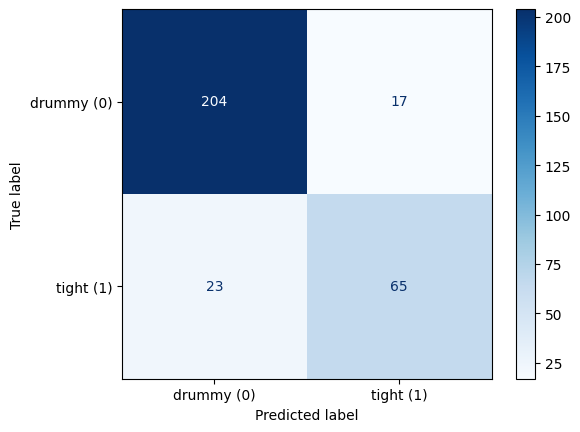


Classification Report:
               precision    recall  f1-score   support

  drummy (0)       0.90      0.92      0.91       221
   tight (1)       0.79      0.74      0.76        88

    accuracy                           0.87       309
   macro avg       0.85      0.83      0.84       309
weighted avg       0.87      0.87      0.87       309



In [18]:
torch.manual_seed(42)
import models.classification as classify
import models.loops as loops
import models.models as models

#90/10 train/test split
train_idx = list(range(0, 3000))
test_idx = list(range(3000,3309))

train_data = torch.utils.data.Subset(P1_zcr, train_idx)
test_data = torch.utils.data.Subset(P1_zcr, test_idx)

batch_size = 90

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

print(train_loader.dataset[0][0].shape)
epochs = 20
model = classify.MLP_3_layer(nb_hidden=128, input_dim=train_loader.dataset[0][0].shape[0], output_dim=2, dropout_rate=0.5)

## loops.train return history of train and validation loss/accuracy use that for plots
## by default device= mps, set as cuda or cpu if you want as an argument in loop.train/test

loops.train(model=model, model_path="./final_model_paths/example_zcr", train_loader=train_loader,val=False, val_loader=None, batch_size=batch_size, lr=1e-3,weight_decay=1e-3, optim="adam", epochs=epochs)

loops.test(model=model, model_path="./final_model_paths/example_zcr", test_loader=test_loader, report=True)

#### Combining pca and temporal features result in good accuracy scores

In [19]:
P1_pca_95 = Extract_Features(P1_df_X, P1_df_Y, feature="pca", explained_variance=0.95)

In [20]:

## concatenate the amplitude envelope, zero crossing rate and rms energy features and pca features using df
def as_df(feat_obj, prefix: str) -> pd.DataFrame:
    X = feat_obj.get_samples()
    # Coerce to DataFrame
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X)
    else:
        X = X.copy()

    # Reset index so all feature blocks align on 0..N-1
    X = X.reset_index(drop=True)

    # Name the columns for traceability
    if X.columns.dtype == 'int64' or any(str(c).isdigit() for c in X.columns):
        X.columns = [f"{prefix}_{i}" for i in range(X.shape[1])]
    else:
        X.columns = [f"{prefix}_{c}" for c in X.columns]
    return X

Xpca = as_df(P1_pca_95, "pca")
Xae  = as_df(P1_amp_env, "ae")
Xzcr = as_df(P1_zcr, "zcr")
Xrms = as_df(P1_rms, "rms")

# --- 3) Labels (reset index for alignment as well) ---
y = P1_pca_95.get_labels()
if isinstance(y, (pd.Series, pd.DataFrame)):
    y = y.reset_index(drop=True)
else:
    y = pd.Series(np.asarray(y)).reset_index(drop=True)
y.name = "label"

# --- 4) Sanity checks before concatenation ---
n = len(y)
for name, block in [("pca", Xpca), ("amplitude_envelope", Xae), ("zcr", Xzcr), ("rms", Xrms)]:
    assert len(block) == n, f"Length mismatch for {name}: got {len(block)} vs labels {n}"

# --- 5) Concatenate features and labels (row-wise aligned) ---
P1_concat = pd.concat([Xpca, Xae, Xzcr, Xrms], axis=1)

# Optional: ensure no NaNs/Infs slipped in
if not np.isfinite(P1_concat.to_numpy()).all():
    P1_concat = P1_concat.replace([np.inf, -np.inf], np.nan).fillna(0.0)

P1_concat_df = pd.concat([P1_concat, y], axis=1)

# --- 6) Shuffle once at the very end ---
shuffled_concat_df = P1_concat_df.sample(frac=1.0, random_state=42).reset_index(drop=True)

# --- 7) Final X, y splits ---
P1_concat_X = shuffled_concat_df.drop(columns=["label"])
P1_concat_Y = shuffled_concat_df["label"]

In [21]:
P1_concat_raw = Extract_Features(P1_concat_X, P1_concat_Y, feature='raw')

In [22]:
print(P1_concat_raw.get_samples().shape, P1_concat_raw.get_labels().shape)

(3309, 1241) (3309,)


torch.Size([1241])
[INFO] EPOCH: 1/20
Train loss: 0.585789, Train accuracy: 0.7157
[INFO] EPOCH: 2/20
Train loss: 0.449268, Train accuracy: 0.8590
[INFO] EPOCH: 3/20
Train loss: 0.352242, Train accuracy: 0.9273
[INFO] EPOCH: 4/20
Train loss: 0.287690, Train accuracy: 0.9687
[INFO] EPOCH: 5/20
Train loss: 0.259169, Train accuracy: 0.9850
[INFO] EPOCH: 6/20
Train loss: 0.245460, Train accuracy: 0.9920
[INFO] EPOCH: 7/20
Train loss: 0.229512, Train accuracy: 0.9987
[INFO] EPOCH: 8/20
Train loss: 0.223793, Train accuracy: 0.9993
[INFO] EPOCH: 9/20
Train loss: 0.219584, Train accuracy: 0.9997
[INFO] EPOCH: 10/20
Train loss: 0.216494, Train accuracy: 0.9997
[INFO] EPOCH: 11/20
Train loss: 0.216305, Train accuracy: 1.0000
[INFO] EPOCH: 12/20
Train loss: 0.215272, Train accuracy: 0.9997
[INFO] EPOCH: 13/20
Train loss: 0.214961, Train accuracy: 1.0000
[INFO] EPOCH: 14/20
Train loss: 0.215139, Train accuracy: 1.0000
[INFO] EPOCH: 15/20
Train loss: 0.214544, Train accuracy: 1.0000
[INFO] EPOCH: 1

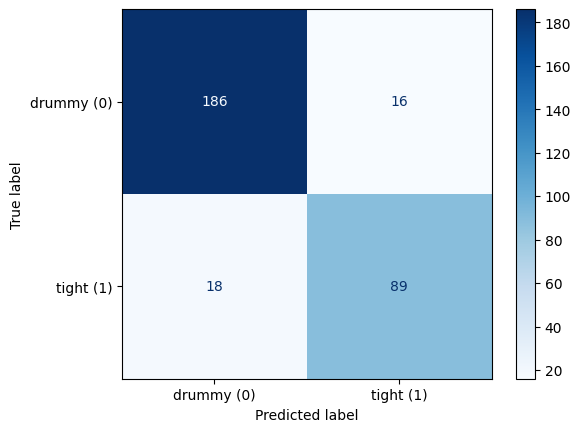


Classification Report:
               precision    recall  f1-score   support

  drummy (0)       0.91      0.92      0.92       202
   tight (1)       0.85      0.83      0.84       107

    accuracy                           0.89       309
   macro avg       0.88      0.88      0.88       309
weighted avg       0.89      0.89      0.89       309



In [26]:
torch.manual_seed(42)
import models.classification as classify
import models.loops as loops
import models.models as models

#90/10 train/test split
train_idx = list(range(0, 3000))
test_idx = list(range(3000,3309))

train_data = torch.utils.data.Subset(P1_concat_raw, train_idx)
test_data = torch.utils.data.Subset(P1_concat_raw, test_idx)

batch_size = 90

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

print(train_loader.dataset[0][0].shape)
epochs = 20
model = classify.MLP_3_layer(nb_hidden=512, input_dim=train_loader.dataset[0][0].shape[0], output_dim=2, dropout_rate=0.5)

## loops.train return history of train and validation loss/accuracy use that for plots
## by default device= mps, set as cuda or cpu if you want as an argument in loop.train/test

loops.train(model=model, model_path="./final_model_paths/combined_pca_time", train_loader=train_loader,val=False, val_loader=None, batch_size=batch_size, lr=1e-3,weight_decay=1e-3, optim="adam", epochs=epochs)

loops.test(model=model, model_path="./final_model_paths/combined_pca_time", test_loader=test_loader, report=True)

#### Repeating the routine for Phase 2 data

In [32]:
frame_size = 128
hop_length = 32

# Note temporal features need frame_size and hop_length as arguments in Extract_Features object
P2_amp_env = Extract_Features(P2_df_X, P2_df_Y, feature="amplitude_envelope", frame_size=frame_size, hop_length=hop_length)
P2_zcr = Extract_Features(P2_df_X, P2_df_Y, feature="zero_crossing_rate", frame_size=frame_size, hop_length=hop_length)
P2_rms = Extract_Features(P2_df_X, P2_df_Y, feature="rms_energy", frame_size=frame_size, hop_length=hop_length)

In [33]:
## This is how you can extract features in the form of numpy arrays
print(P2_amp_env.get_samples().shape, P2_amp_env.get_labels().shape)
print(P2_zcr.get_samples().shape, P2_zcr.get_labels().shape)
print(P2_rms.get_samples().shape, P2_rms.get_labels().shape)

(8229, 147) (8229,)
(8229, 151) (8229,)
(8229, 151) (8229,)


In [34]:
P2_PCA_95 = Extract_Features(P2_df_X, P2_df_Y, feature="pca", explained_variance=0.95)
print(P2_PCA_95.get_samples().shape, P2_PCA_95.get_labels().shape)

(8229, 241) (8229,)


In [35]:

## concatenate the amplitude envelope, zero crossing rate and rms energy features and pca features using df
def as_df(feat_obj, prefix: str) -> pd.DataFrame:
    X = feat_obj.get_samples()
    # Coerce to DataFrame
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X)
    else:
        X = X.copy()

    # Reset index so all feature blocks align on 0..N-1
    X = X.reset_index(drop=True)

    # Name the columns for traceability
    if X.columns.dtype == 'int64' or any(str(c).isdigit() for c in X.columns):
        X.columns = [f"{prefix}_{i}" for i in range(X.shape[1])]
    else:
        X.columns = [f"{prefix}_{c}" for c in X.columns]
    return X

Xpca = as_df(P2_PCA_95, "pca")
Xae  = as_df(P2_amp_env, "ae")
Xzcr = as_df(P2_zcr, "zcr")
Xrms = as_df(P2_rms, "rms")

# --- 3) Labels (reset index for alignment as well) ---
y = P2_PCA_95.get_labels()
if isinstance(y, (pd.Series, pd.DataFrame)):
    y = y.reset_index(drop=True)
else:
    y = pd.Series(np.asarray(y)).reset_index(drop=True)
y.name = "label"

# --- 4) Sanity checks before concatenation ---
n = len(y)
for name, block in [("pca", Xpca), ("amplitude_envelope", Xae), ("zcr", Xzcr), ("rms", Xrms)]:
    assert len(block) == n, f"Length mismatch for {name}: got {len(block)} vs labels {n}"

# --- 5) Concatenate features and labels (row-wise aligned) ---
P2_concat = pd.concat([Xpca, Xae, Xzcr, Xrms], axis=1)

# Optional: ensure no NaNs/Infs slipped in
if not np.isfinite(P2_concat.to_numpy()).all():
    P2_concat = P2_concat.replace([np.inf, -np.inf], np.nan).fillna(0.0)

P2_concat_df = pd.concat([P2_concat, y], axis=1)

# --- 6) Shuffle once at the very end ---
shuffled_concat_df = P2_concat_df.sample(frac=1.0, random_state=42).reset_index(drop=True)

# --- 7) Final X, y splits ---
P2_concat_X = shuffled_concat_df.drop(columns=["label"])
P2_concat_Y = shuffled_concat_df["label"]

In [36]:
P2_concat_raw = Extract_Features(P2_concat_X, P2_concat_Y, feature='raw')
print(P2_concat_raw.get_samples().shape, P2_concat_raw.get_labels().shape)

(8229, 690) (8229,)


torch.Size([690])
[INFO] EPOCH: 1/20
Train loss: 0.636974, Train accuracy: 0.6588
[INFO] EPOCH: 2/20
Train loss: 0.501517, Train accuracy: 0.8027
[INFO] EPOCH: 3/20
Train loss: 0.407604, Train accuracy: 0.8782
[INFO] EPOCH: 4/20
Train loss: 0.335807, Train accuracy: 0.9305
[INFO] EPOCH: 5/20
Train loss: 0.294014, Train accuracy: 0.9570
[INFO] EPOCH: 6/20
Train loss: 0.261641, Train accuracy: 0.9796
[INFO] EPOCH: 7/20
Train loss: 0.243158, Train accuracy: 0.9901
[INFO] EPOCH: 8/20
Train loss: 0.229645, Train accuracy: 0.9961
[INFO] EPOCH: 9/20
Train loss: 0.217707, Train accuracy: 0.9997
[INFO] EPOCH: 10/20
Train loss: 0.212153, Train accuracy: 0.9999
[INFO] EPOCH: 11/20
Train loss: 0.210234, Train accuracy: 0.9999
[INFO] EPOCH: 12/20
Train loss: 0.208828, Train accuracy: 0.9999
[INFO] EPOCH: 13/20
Train loss: 0.208228, Train accuracy: 0.9996
[INFO] EPOCH: 14/20
Train loss: 0.208198, Train accuracy: 0.9999
[INFO] EPOCH: 15/20
Train loss: 0.207703, Train accuracy: 0.9999
[INFO] EPOCH: 16

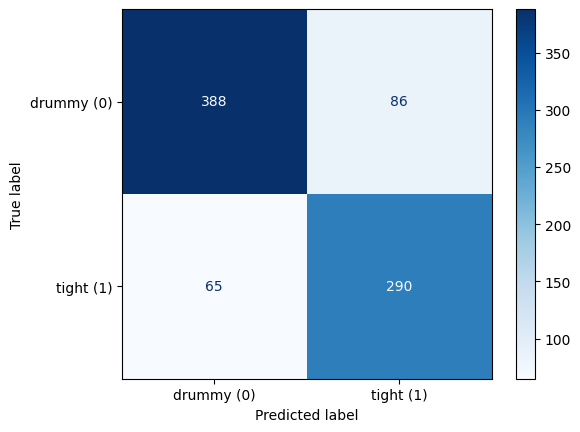


Classification Report:
               precision    recall  f1-score   support

  drummy (0)       0.86      0.82      0.84       474
   tight (1)       0.77      0.82      0.79       355

    accuracy                           0.82       829
   macro avg       0.81      0.82      0.82       829
weighted avg       0.82      0.82      0.82       829



In [47]:
torch.manual_seed(42)
import models.classification as classify
import models.loops as loops
import models.models as models

#90/10 train/test split
train_idx = list(range(0, 7400))
test_idx = list(range(7400,8229))

train_data = torch.utils.data.Subset(P2_concat_raw, train_idx)
test_data = torch.utils.data.Subset(P2_concat_raw, test_idx)

batch_size = 90

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

print(train_loader.dataset[0][0].shape)
epochs = 20
model = classify.MLP_3_layer(nb_hidden=512, input_dim=train_loader.dataset[0][0].shape[0], output_dim=2, dropout_rate=0.5)

## loops.train return history of train and validation loss/accuracy use that for plots
## by default device= mps, set as cuda or cpu if you want as an argument in loop.train/test

loops.train(model=model, model_path="./final_model_paths/combined_pca_time", train_loader=train_loader,val=False, val_loader=None, batch_size=batch_size, lr=1e-3,weight_decay=1e-3, optim="adam", epochs=epochs)

loops.test(model=model, model_path="./final_model_paths/combined_pca_time", test_loader=test_loader, report=True)

# Deep Learning Models

### Phase 1

#### Convolution (ResNet End-to-End)

##### Train vs Validation to find the best epoch to train

In [5]:
import models.classification as classify
import models.loops as loops
import models.models as models

train_idx = list(range(0, 2900))
val_idx = list(range(2900,3000))
test_idx = list(range(3000,3309))

train_data = torch.utils.data.Subset(P1_raw, train_idx)
val_data = torch.utils.data.Subset(P1_raw, val_idx)
test_data = torch.utils.data.Subset(P1_raw, test_idx)

batch_size = 30

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

model = models.Convolution()
epochs = 50

history = loops.train(model=model, model_path="./final_model_paths/convolution_p1.pth", train_loader=train_loader,val=True, val_loader = val_loader, batch_size=batch_size, lr=1e-3,weight_decay=0, optim="adam", epochs=epochs)

loops.test(model=model,model_path="./final_model_paths/convolution_p1.pth", test_loader=test_loader, report=True)

plt.plot(list(range(1,epochs+1)), history["train_acc"], label="Train Accuracy")
plt.plot(list(range(1,epochs+1)), history["val_acc"],   label="Validation Accuracy")
plt.title("Accuracy vs. Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

[INFO] EPOCH: 1/50
Train loss: 0.664030, Train accuracy: 0.6628
Val loss: 0.864972, Val accuracy: 0.6600



KeyboardInterrupt: 

##### Test routine

[INFO] EPOCH: 1/20
Train loss: 0.644960, Train accuracy: 0.6597
[INFO] EPOCH: 2/20
Train loss: 0.547493, Train accuracy: 0.7330
[INFO] EPOCH: 3/20
Train loss: 0.444429, Train accuracy: 0.8480
[INFO] EPOCH: 4/20
Train loss: 0.406550, Train accuracy: 0.8767
[INFO] EPOCH: 5/20
Train loss: 0.376269, Train accuracy: 0.9030
[INFO] EPOCH: 6/20
Train loss: 0.348067, Train accuracy: 0.9200
[INFO] EPOCH: 7/20
Train loss: 0.329367, Train accuracy: 0.9370
[INFO] EPOCH: 8/20
Train loss: 0.319035, Train accuracy: 0.9473
[INFO] EPOCH: 9/20
Train loss: 0.307100, Train accuracy: 0.9533
[INFO] EPOCH: 10/20
Train loss: 0.290323, Train accuracy: 0.9683
[INFO] EPOCH: 11/20
Train loss: 0.285490, Train accuracy: 0.9700
[INFO] EPOCH: 12/20
Train loss: 0.282588, Train accuracy: 0.9740
[INFO] EPOCH: 13/20
Train loss: 0.279901, Train accuracy: 0.9780
[INFO] EPOCH: 14/20
Train loss: 0.270787, Train accuracy: 0.9823
[INFO] EPOCH: 15/20
Train loss: 0.269320, Train accuracy: 0.9830
[INFO] EPOCH: 16/20
Train loss: 0.

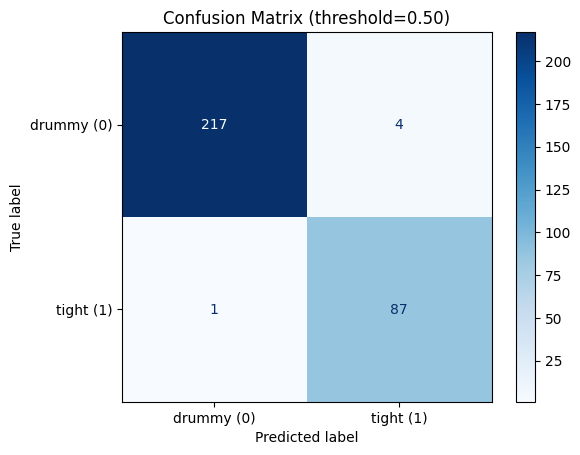

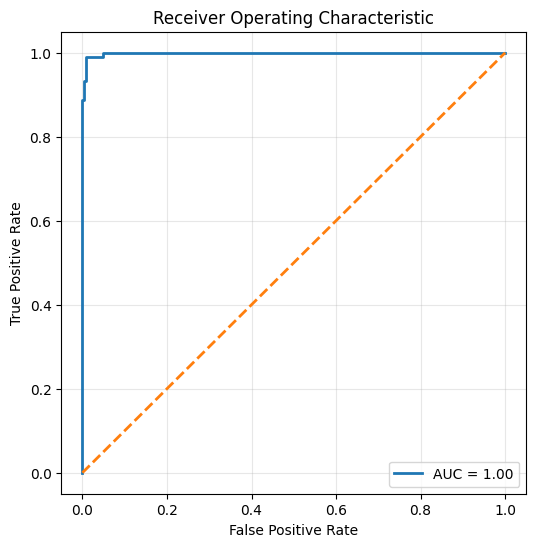


Classification Report (threshold = 0.50):
               precision    recall  f1-score   support

  drummy (0)       1.00      0.98      0.99       221
   tight (1)       0.96      0.99      0.97        88

    accuracy                           0.98       309
   macro avg       0.98      0.99      0.98       309
weighted avg       0.98      0.98      0.98       309



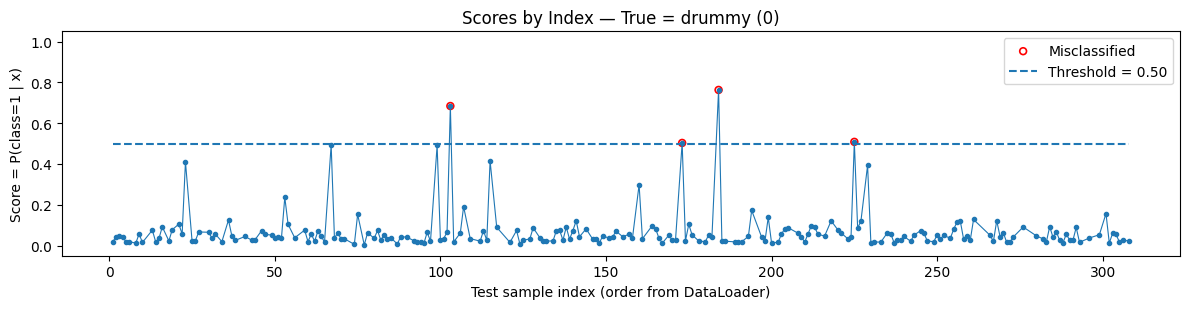

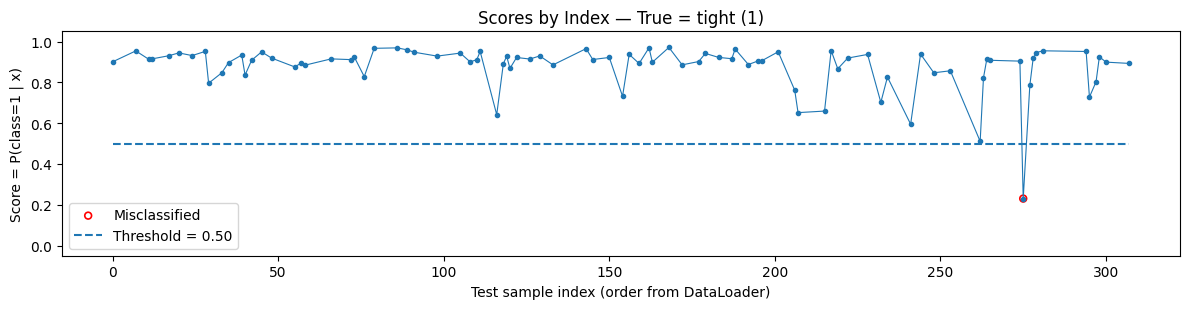

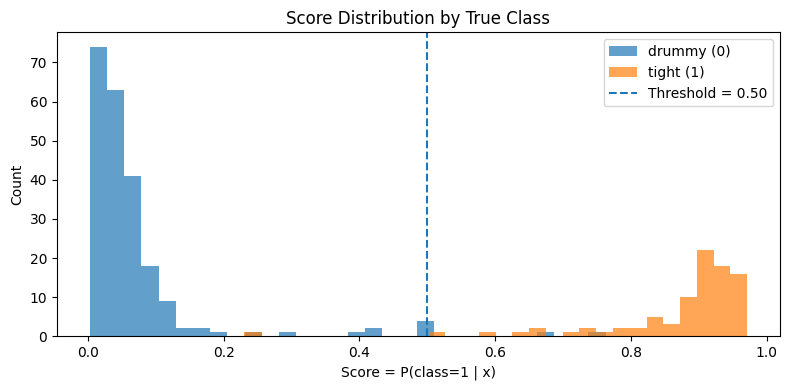

In [4]:
torch.manual_seed(42)
import models.classification as classify
import models.loops as loops
import models.models as models

train_idx = list(range(0, 3000))
# val_idx = list(range(2900,3000))
test_idx = list(range(3000,3309))

train_data = torch.utils.data.Subset(P1_raw, train_idx)
# val_data = torch.utils.data.Subset(data, val_idx)
test_data = torch.utils.data.Subset(P1_raw, test_idx)

batch_size = 30

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
# val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

model = models.Convolution()
epochs = 20

loops.train(model=model, model_path="./model_paths/convolution_p1_test.pth", train_loader=train_loader,val=False,val_loader=None, batch_size=batch_size, lr=1e-3,weight_decay=0, optim="adam", epochs=epochs)

loops.test(model= model,model_path="./model_paths/convolution_p1_test.pth", test_loader=test_loader, report=True)

# plt.plot(list(range(1,epochs+1)), history["train_acc"], label="Train Accuracy")
# plt.plot(list(range(1,epochs+1)), history["val_acc"],   label="Validation Accuracy")
# plt.title("Accuracy vs. Epochs")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")
# plt.legend()
# plt.show()

## Phase 2

### Convolution (ResNet End-to-End)

##### Train/Val Routine

torch.Size([4800])
[INFO] EPOCH: 1/50
Train loss: 0.661133, Train accuracy: 0.6170
Val loss: 0.665942, Val accuracy: 0.7500

[INFO] EPOCH: 2/50
Train loss: 0.591415, Train accuracy: 0.7326
Val loss: 0.628470, Val accuracy: 0.7600

[INFO] EPOCH: 3/50
Train loss: 0.565164, Train accuracy: 0.7586
Val loss: 0.564930, Val accuracy: 0.7875

[INFO] EPOCH: 4/50
Train loss: 0.520133, Train accuracy: 0.7924
Val loss: 0.537161, Val accuracy: 0.7863

[INFO] EPOCH: 5/50
Train loss: 0.494861, Train accuracy: 0.8067
Val loss: 0.564527, Val accuracy: 0.7837

[INFO] EPOCH: 6/50
Train loss: 0.461809, Train accuracy: 0.8292
Val loss: 0.553559, Val accuracy: 0.7825

[INFO] EPOCH: 7/50
Train loss: 0.432530, Train accuracy: 0.8600
Val loss: 0.498174, Val accuracy: 0.8325

[INFO] EPOCH: 8/50
Train loss: 0.407010, Train accuracy: 0.8788
Val loss: 0.493556, Val accuracy: 0.8313

[INFO] EPOCH: 9/50
Train loss: 0.389695, Train accuracy: 0.8894
Val loss: 0.485407, Val accuracy: 0.8400

[INFO] EPOCH: 10/50
Train l

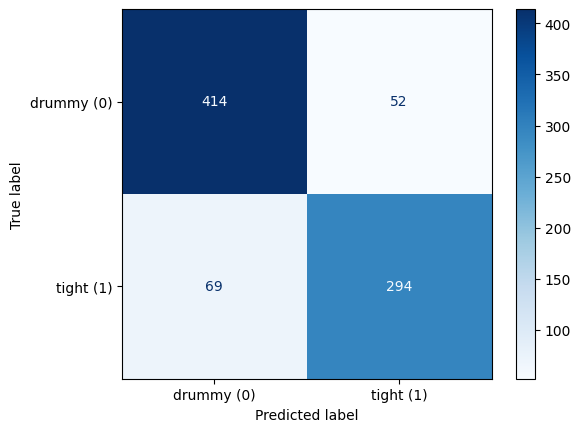


Classification Report:
               precision    recall  f1-score   support

  drummy (0)       0.86      0.89      0.87       466
   tight (1)       0.85      0.81      0.83       363

    accuracy                           0.85       829
   macro avg       0.85      0.85      0.85       829
weighted avg       0.85      0.85      0.85       829



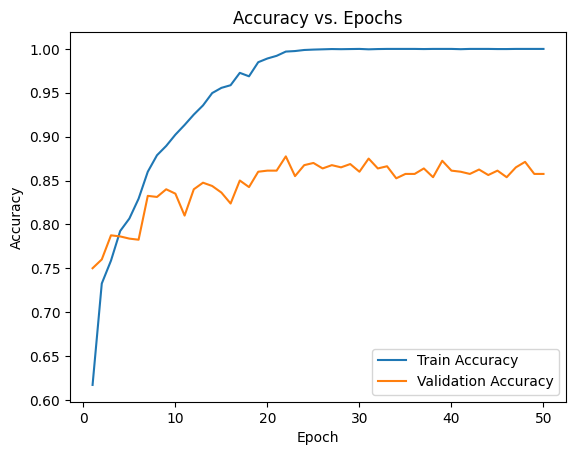

In [53]:
torch.manual_seed(42)
import matplotlib.pyplot as plt
import models.classification as classify
import models.loops as loops
import models.models as models

train_idx = list(range(0, 6600))
val_idx = list(range(6600,7400))
test_idx = list(range(7400,8229))

train_data = torch.utils.data.Subset(P2_raw, train_idx)
val_data = torch.utils.data.Subset(P2_raw, val_idx)
test_data = torch.utils.data.Subset(P2_raw, test_idx)

batch_size = 90

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

epochs = 50

print(train_loader.dataset[0][0].shape)

model = models.Convolution_p2()

history = loops.train(model=model, model_path="./model_paths/mfcc_p2.pth", train_loader=train_loader,val=True, val_loader=val_loader, batch_size=batch_size, lr=1e-3,weight_decay=0, optim="adam", epochs=epochs)

loops.test(model=model, model_path="./model_paths/mfcc_p2.pth", test_loader=test_loader, report=True)

plt.plot(list(range(1,epochs+1)), history["train_acc"], label="Train Accuracy")
plt.plot(list(range(1,epochs+1)), history["val_acc"],   label="Validation Accuracy")
plt.title("Accuracy vs. Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

##### Test Routine

torch.Size([4800])
[INFO] EPOCH: 1/20
Train loss: 0.650288, Train accuracy: 0.6431
[INFO] EPOCH: 2/20
Train loss: 0.569106, Train accuracy: 0.7461
[INFO] EPOCH: 3/20
Train loss: 0.525637, Train accuracy: 0.7842
[INFO] EPOCH: 4/20
Train loss: 0.485775, Train accuracy: 0.8112
[INFO] EPOCH: 5/20
Train loss: 0.462345, Train accuracy: 0.8369
[INFO] EPOCH: 6/20
Train loss: 0.438678, Train accuracy: 0.8531
[INFO] EPOCH: 7/20
Train loss: 0.421554, Train accuracy: 0.8646
[INFO] EPOCH: 8/20
Train loss: 0.396171, Train accuracy: 0.8800
[INFO] EPOCH: 9/20
Train loss: 0.379324, Train accuracy: 0.8970
[INFO] EPOCH: 10/20
Train loss: 0.360616, Train accuracy: 0.9134
[INFO] EPOCH: 11/20
Train loss: 0.346777, Train accuracy: 0.9211
[INFO] EPOCH: 12/20
Train loss: 0.332129, Train accuracy: 0.9315
[INFO] EPOCH: 13/20
Train loss: 0.321183, Train accuracy: 0.9396
[INFO] EPOCH: 14/20
Train loss: 0.298242, Train accuracy: 0.9554
[INFO] EPOCH: 15/20
Train loss: 0.291662, Train accuracy: 0.9601
[INFO] EPOCH: 1

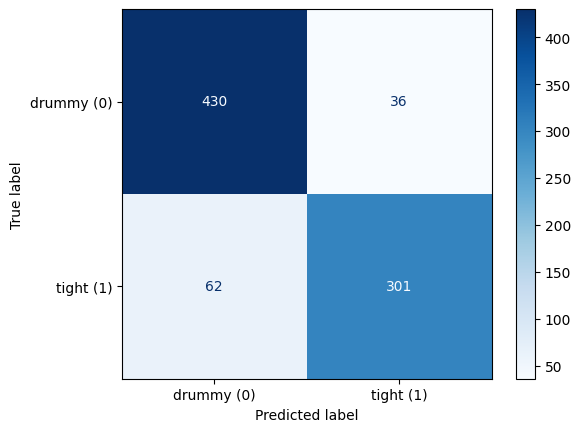


Classification Report:
               precision    recall  f1-score   support

  drummy (0)       0.87      0.92      0.90       466
   tight (1)       0.89      0.83      0.86       363

    accuracy                           0.88       829
   macro avg       0.88      0.88      0.88       829
weighted avg       0.88      0.88      0.88       829



In [54]:
torch.manual_seed(42)
import models.classification as classify
import models.loops as loops
import models.models as models

train_idx = list(range(0, 7400))
test_idx = list(range(7400,8229))

train_data = torch.utils.data.Subset(P2_raw, train_idx)
test_data = torch.utils.data.Subset(P2_raw, test_idx)

batch_size = 90

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

print(train_loader.dataset[0][0].shape)
epochs = 20
model = models.Convolution_p2()

loops.train(model=model, model_path="./model_paths/raw_p2_conv.pth", train_loader=train_loader,val=False, val_loader=None, batch_size=batch_size, lr=1e-3,weight_decay=1e-3, optim="adam", epochs=epochs)

loops.test(model=model, model_path="./model_paths/raw_p2_conv.pth", test_loader=test_loader, report=True)

### MFCC + MLP

#### Train/Val Routine

torch.Size([4800])
[INFO] EPOCH: 1/50
Train loss: 0.793434, Train accuracy: 0.6745
Val loss: 0.562851, Val accuracy: 0.7837

[INFO] EPOCH: 2/50
Train loss: 0.539963, Train accuracy: 0.7703
Val loss: 0.520426, Val accuracy: 0.8275

[INFO] EPOCH: 3/50
Train loss: 0.499995, Train accuracy: 0.8030
Val loss: 0.492737, Val accuracy: 0.8400

[INFO] EPOCH: 4/50
Train loss: 0.471858, Train accuracy: 0.8280
Val loss: 0.483391, Val accuracy: 0.8325

[INFO] EPOCH: 5/50
Train loss: 0.459064, Train accuracy: 0.8370
Val loss: 0.479970, Val accuracy: 0.8525

[INFO] EPOCH: 6/50
Train loss: 0.444898, Train accuracy: 0.8530
Val loss: 0.456670, Val accuracy: 0.8612

[INFO] EPOCH: 7/50
Train loss: 0.438488, Train accuracy: 0.8511
Val loss: 0.444289, Val accuracy: 0.8662

[INFO] EPOCH: 8/50
Train loss: 0.425725, Train accuracy: 0.8612
Val loss: 0.445766, Val accuracy: 0.8612

[INFO] EPOCH: 9/50
Train loss: 0.412138, Train accuracy: 0.8744
Val loss: 0.429462, Val accuracy: 0.8750

[INFO] EPOCH: 10/50
Train l

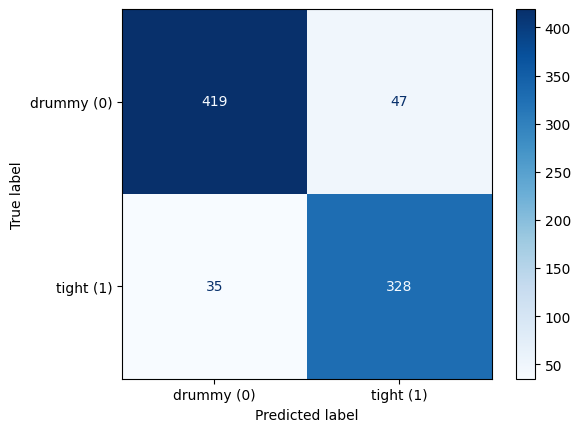


Classification Report:
               precision    recall  f1-score   support

  drummy (0)       0.92      0.90      0.91       466
   tight (1)       0.87      0.90      0.89       363

    accuracy                           0.90       829
   macro avg       0.90      0.90      0.90       829
weighted avg       0.90      0.90      0.90       829



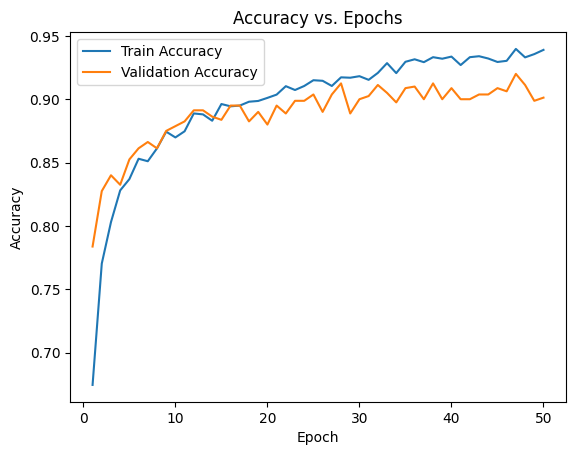

In [56]:
torch.manual_seed(42)
import matplotlib.pyplot as plt
import models.classification as classify
import models.loops as loops
import models.models as models

train_idx = list(range(0, 6600))
val_idx = list(range(6600,7400))
test_idx = list(range(7400,8229))

train_data = torch.utils.data.Subset(P2_raw, train_idx)
val_data = torch.utils.data.Subset(P2_raw, val_idx)
test_data = torch.utils.data.Subset(P2_raw, test_idx)

batch_size = 90

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

epochs = 50

print(train_loader.dataset[0][0].shape)

model = models.MFCC()

history = loops.train(model=model, model_path="./final_model_paths/mfcc_p2_val.pth", train_loader=train_loader,val=True, val_loader=val_loader, batch_size=batch_size, lr=1e-3,weight_decay=0, optim="adam", epochs=epochs)

loops.test(model=model, model_path="./final_model_paths/mfcc_p2_val.pth", test_loader=test_loader, report=True)

plt.plot(list(range(1,epochs+1)), history["train_acc"], label="Train Accuracy")
plt.plot(list(range(1,epochs+1)), history["val_acc"],   label="Validation Accuracy")
plt.title("Accuracy vs. Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


#### Test Routine

torch.Size([4800])
[INFO] EPOCH: 1/20
Train loss: 0.739754, Train accuracy: 0.6977
[INFO] EPOCH: 2/20
Train loss: 0.523747, Train accuracy: 0.7822
[INFO] EPOCH: 3/20
Train loss: 0.491405, Train accuracy: 0.8086
[INFO] EPOCH: 4/20
Train loss: 0.470831, Train accuracy: 0.8293
[INFO] EPOCH: 5/20
Train loss: 0.452240, Train accuracy: 0.8403
[INFO] EPOCH: 6/20
Train loss: 0.441934, Train accuracy: 0.8478
[INFO] EPOCH: 7/20
Train loss: 0.433173, Train accuracy: 0.8509
[INFO] EPOCH: 8/20
Train loss: 0.415415, Train accuracy: 0.8635
[INFO] EPOCH: 9/20
Train loss: 0.415735, Train accuracy: 0.8680
[INFO] EPOCH: 10/20
Train loss: 0.410418, Train accuracy: 0.8695
[INFO] EPOCH: 11/20
Train loss: 0.402760, Train accuracy: 0.8791
[INFO] EPOCH: 12/20
Train loss: 0.403018, Train accuracy: 0.8800
[INFO] EPOCH: 13/20
Train loss: 0.395717, Train accuracy: 0.8859
[INFO] EPOCH: 14/20
Train loss: 0.397459, Train accuracy: 0.8827
[INFO] EPOCH: 15/20
Train loss: 0.393386, Train accuracy: 0.8881
[INFO] EPOCH: 1

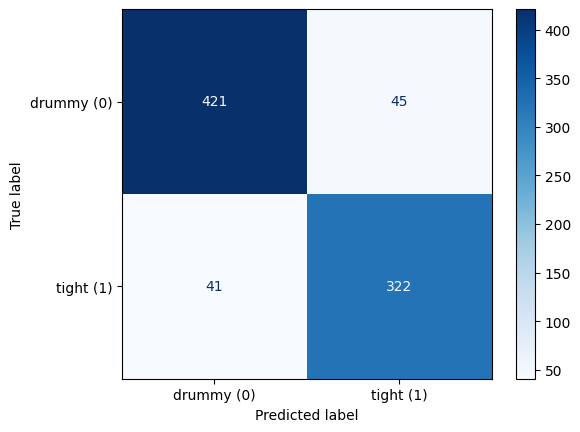


Classification Report:
               precision    recall  f1-score   support

  drummy (0)       0.91      0.90      0.91       466
   tight (1)       0.88      0.89      0.88       363

    accuracy                           0.90       829
   macro avg       0.89      0.90      0.89       829
weighted avg       0.90      0.90      0.90       829



In [57]:
torch.manual_seed(42)
import matplotlib.pyplot as plt
import models.classification as classify
import models.loops as loops
import models.models as models

train_idx = list(range(0, 7400))
test_idx = list(range(7400,8229))

train_data = torch.utils.data.Subset(P2_raw, train_idx)
test_data = torch.utils.data.Subset(P2_raw, test_idx)

batch_size = 90

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

epochs = 20

print(train_loader.dataset[0][0].shape)

model = models.MFCC()

loops.train(model=model, model_path="./final_model_paths/end_mfcc_p2_test.pth", train_loader=train_loader,val=False, val_loader=None, batch_size=batch_size, lr=1e-3,weight_decay=0, optim="adam", epochs=epochs)

loops.test(model=model, model_path="./final_model_paths/end_mfcc_p2_test.pth", test_loader=test_loader, report=True)


### MFCC + ResNet

#### Train/Val Routine

torch.Size([4800])
[INFO] EPOCH: 1/50
Train loss: 0.592020, Train accuracy: 0.7161
Val loss: 0.532930, Val accuracy: 0.7963

[INFO] EPOCH: 2/50
Train loss: 0.489229, Train accuracy: 0.8074
Val loss: 0.471059, Val accuracy: 0.8413

[INFO] EPOCH: 3/50
Train loss: 0.444595, Train accuracy: 0.8465
Val loss: 0.472417, Val accuracy: 0.8512

[INFO] EPOCH: 4/50
Train loss: 0.410399, Train accuracy: 0.8809
Val loss: 0.434509, Val accuracy: 0.8750

[INFO] EPOCH: 5/50
Train loss: 0.387616, Train accuracy: 0.8983
Val loss: 0.414353, Val accuracy: 0.8875

[INFO] EPOCH: 6/50
Train loss: 0.368685, Train accuracy: 0.9052
Val loss: 0.411948, Val accuracy: 0.8912

[INFO] EPOCH: 7/50
Train loss: 0.351596, Train accuracy: 0.9171
Val loss: 0.404124, Val accuracy: 0.9062

[INFO] EPOCH: 8/50
Train loss: 0.330615, Train accuracy: 0.9365
Val loss: 0.421873, Val accuracy: 0.9012

[INFO] EPOCH: 9/50
Train loss: 0.331438, Train accuracy: 0.9317
Val loss: 0.391767, Val accuracy: 0.9175

[INFO] EPOCH: 10/50
Train l

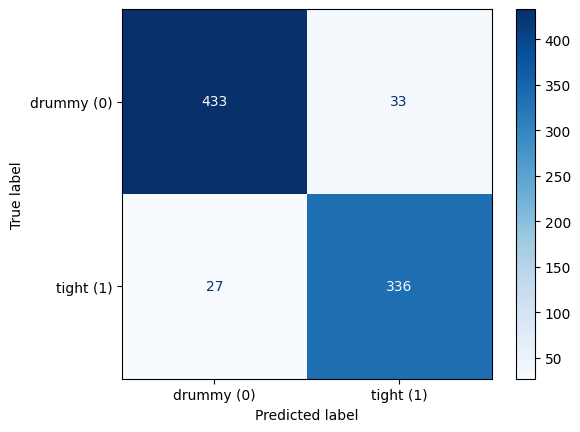


Classification Report:
               precision    recall  f1-score   support

  drummy (0)       0.94      0.93      0.94       466
   tight (1)       0.91      0.93      0.92       363

    accuracy                           0.93       829
   macro avg       0.93      0.93      0.93       829
weighted avg       0.93      0.93      0.93       829



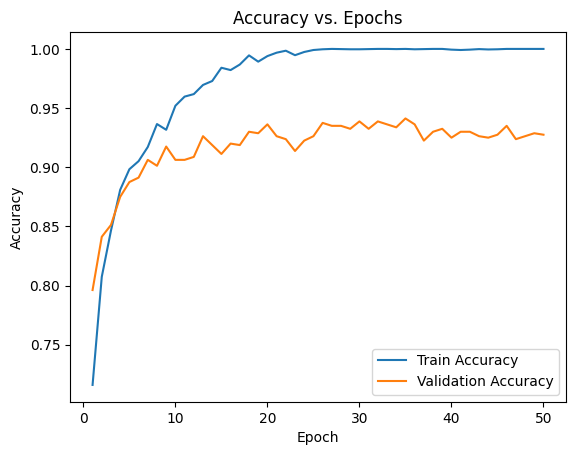

In [58]:
torch.manual_seed(42)
import matplotlib.pyplot as plt
import models.classification as classify
import models.loops as loops
import models.models as models

train_idx = list(range(0, 6600))
val_idx = list(range(6600,7400))
test_idx = list(range(7400,8229))

train_data = torch.utils.data.Subset(P2_raw, train_idx)
val_data = torch.utils.data.Subset(P2_raw, val_idx)
test_data = torch.utils.data.Subset(P2_raw, test_idx)

batch_size = 90

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

epochs = 50

print(train_loader.dataset[0][0].shape)

model = models.ConvPlusMFCC()

history = loops.train(model=model, model_path="./final_model_paths/conv_mfcc.pth", train_loader=train_loader,val=True, val_loader=val_loader, batch_size=batch_size, lr=1e-3,weight_decay=0, optim="adam", epochs=epochs)

loops.test(model=model, model_path="./final_model_paths/conv_mfcc.pth", test_loader=test_loader, report=True)

plt.plot(list(range(1,epochs+1)), history["train_acc"], label="Train Accuracy")
plt.plot(list(range(1,epochs+1)), history["val_acc"],   label="Validation Accuracy")
plt.title("Accuracy vs. Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#### Test Routine

torch.Size([4800])
[INFO] EPOCH: 1/20
Train loss: 0.590429, Train accuracy: 0.7085
[INFO] EPOCH: 2/20
Train loss: 0.485300, Train accuracy: 0.8209
[INFO] EPOCH: 3/20
Train loss: 0.429810, Train accuracy: 0.8576
[INFO] EPOCH: 4/20
Train loss: 0.400706, Train accuracy: 0.8805
[INFO] EPOCH: 5/20
Train loss: 0.379609, Train accuracy: 0.8938
[INFO] EPOCH: 6/20
Train loss: 0.355009, Train accuracy: 0.9180
[INFO] EPOCH: 7/20
Train loss: 0.341375, Train accuracy: 0.9277
[INFO] EPOCH: 8/20
Train loss: 0.332468, Train accuracy: 0.9338
[INFO] EPOCH: 9/20
Train loss: 0.313198, Train accuracy: 0.9480
[INFO] EPOCH: 10/20
Train loss: 0.308310, Train accuracy: 0.9523
[INFO] EPOCH: 11/20
Train loss: 0.291396, Train accuracy: 0.9645
[INFO] EPOCH: 12/20
Train loss: 0.281205, Train accuracy: 0.9707
[INFO] EPOCH: 13/20
Train loss: 0.272428, Train accuracy: 0.9766
[INFO] EPOCH: 14/20
Train loss: 0.264367, Train accuracy: 0.9828
[INFO] EPOCH: 15/20
Train loss: 0.258378, Train accuracy: 0.9849
[INFO] EPOCH: 1

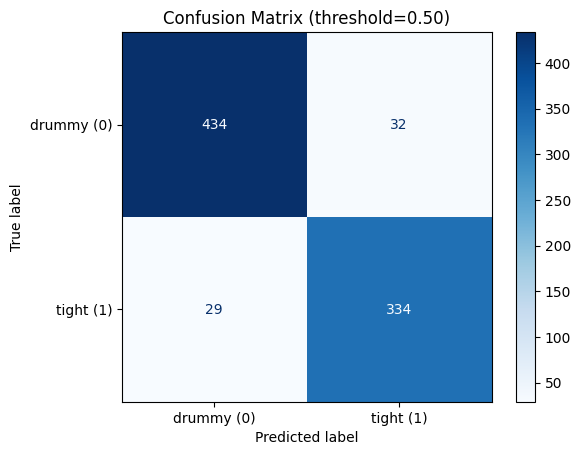

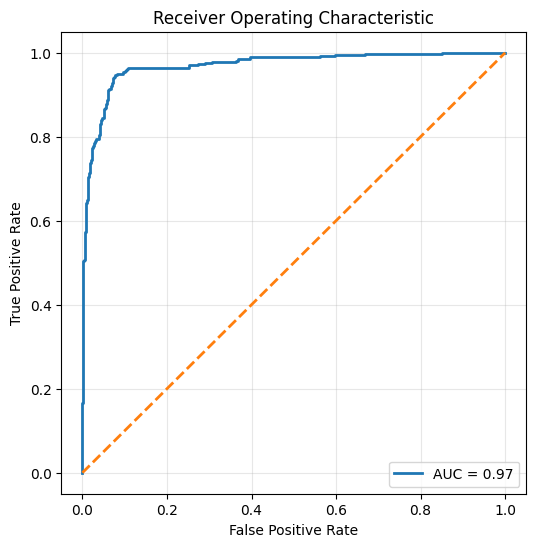


Classification Report (threshold = 0.50):
               precision    recall  f1-score   support

  drummy (0)       0.94      0.93      0.93       466
   tight (1)       0.91      0.92      0.92       363

    accuracy                           0.93       829
   macro avg       0.92      0.93      0.93       829
weighted avg       0.93      0.93      0.93       829



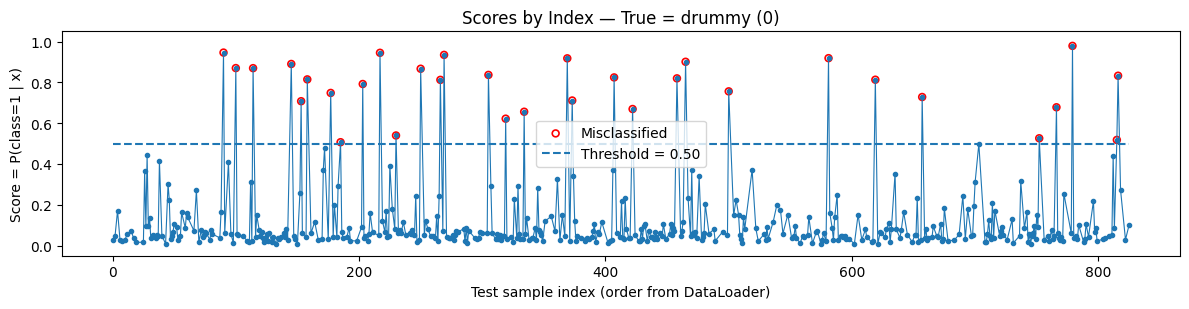

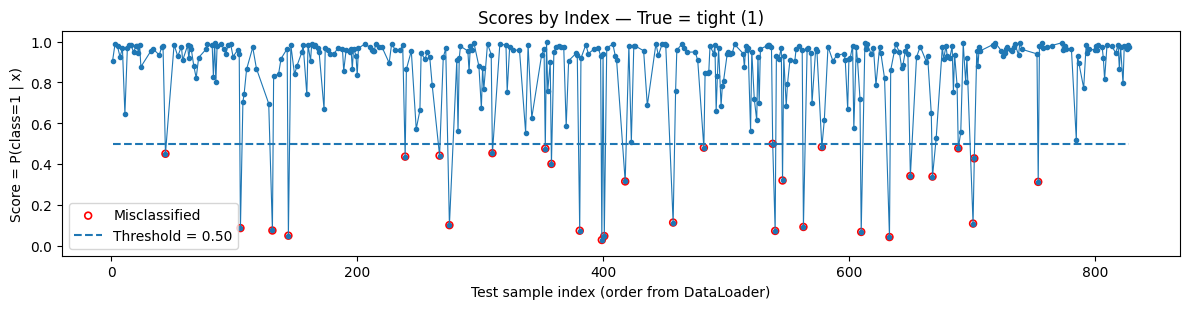

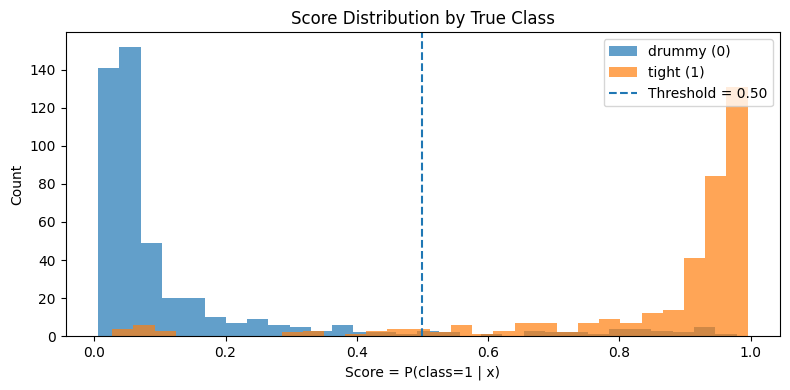

In [7]:
torch.manual_seed(42)
import matplotlib.pyplot as plt
import models.classification as classify
import models.loops as loops
import models.models as models

train_idx = list(range(0, 7400))
test_idx = list(range(7400,8229))

train_data = torch.utils.data.Subset(P2_raw, train_idx)
test_data = torch.utils.data.Subset(P2_raw, test_idx)

batch_size = 90

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

epochs = 20

print(train_loader.dataset[0][0].shape)

model = models.ConvPlusMFCC()

loops.train(model=model, model_path="./final_model_paths/conv_mfcc_p2_test.pth", train_loader=train_loader,val=False, val_loader=None, batch_size=batch_size, lr=1e-3,weight_decay=0, optim="adam", epochs=epochs)

loops.test(model=model, model_path="./final_model_paths/conv_mfcc_p2_test.pth", test_loader=test_loader, report=True)